In [1]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [2]:
data = fetch_dataset(name = 'expenditures_australia')
data.index.name = 'datetime'

╭───────────────────────────── expenditures_australia ─────────────────────────────╮
│ Description:                                                                     │
│ Monthly expenditure on cafes, restaurants and takeaway food services in Victoria │
│ (Australia) from April 1982 up to April 2024.                                    │
│                                                                                  │
│ Source:                                                                          │
│ Australian Bureau of Statistics. Catalogue No. 8501.0                            │
│ https://www.abs.gov.au/statistics/industry/retail-and-wholesale-trade/retail-    │
│ trade-australia/apr-2024/8501011.xlsx                                            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/refs/heads/main/data/expenditures_australia.csv                         │
│                                                                                  │
│ Shape: 505 rows x 1 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [3]:
data

,turnover
datetime,
1982-04-01,85.1
1982-05-01,85.1
1982-06-01,82.8
1982-07-01,82.1
1982-08-01,81.8
...,...
2023-12-01,1508.8
2024-01-01,1358.3
2024-02-01,1294.8


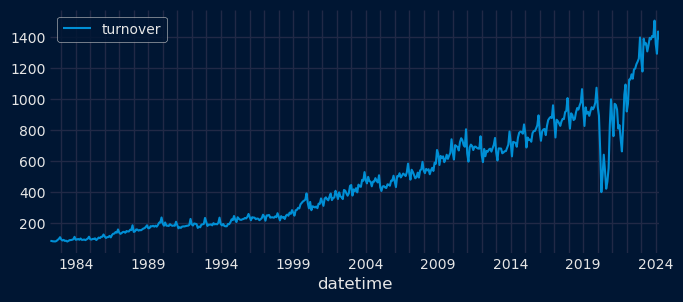

In [4]:
from skforecast.plot import set_dark_theme
set_dark_theme()
# **5. Exploracion de datos**
fig, ax = plt.subplots(figsize=(7, 3))
data.plot(ax=ax)
ax.legend()
plt.show()

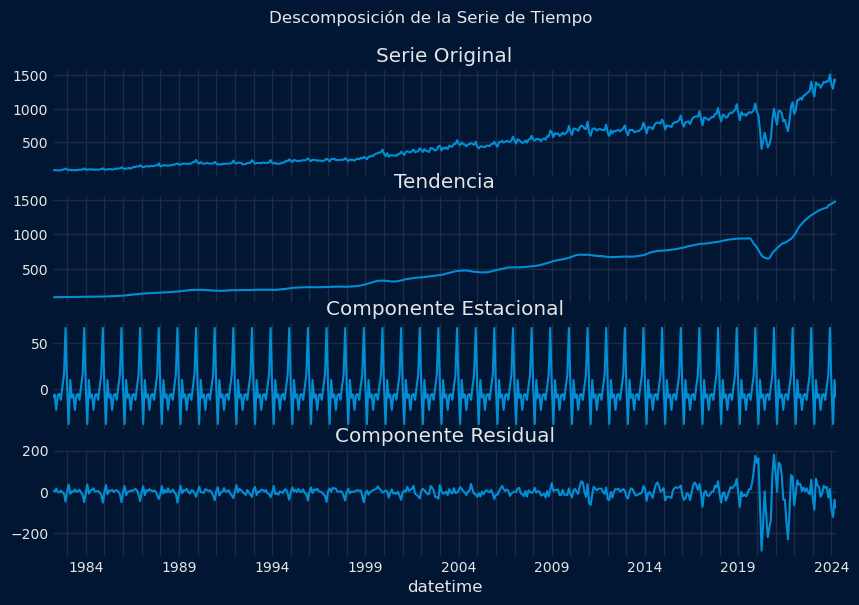

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
res_descompose = seasonal_decompose(data['turnover'], model='additive', extrapolate_trend='freq')
fig, ax = plt.subplots(4, 1, figsize=(9, 6), sharex=True)
res_descompose.observed.plot(ax=ax[0])
ax[0].set_title('Serie Original')
res_descompose.trend.plot(ax=ax[1])
ax[1].set_title('Tendencia')
res_descompose.seasonal.plot(ax=ax[2])
ax[2].set_title('Componente Estacional')
res_descompose.resid.plot(ax=ax[3])
ax[3].set_title('Componente Residual')
fig.suptitle('Descomposición de la Serie de Tiempo')
plt.show()

#### Diferenciación logaritmica 

Se ve que hay una tendencia pero es exponencial así que le aplicaremos un log para poderla diferenciar correctamente

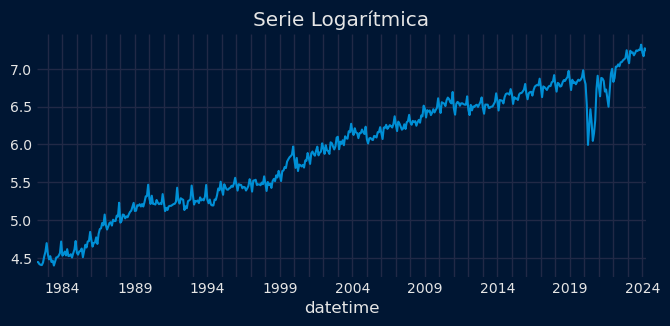

In [6]:
import numpy as np
data_log = np.log(data['turnover'])
fig, ax = plt.subplots(figsize=(7, 3))
data_log.plot(ax=ax)
ax.set_title('Serie Logarítmica')
plt.show()


#### Etacionariedad:

Se puede ver claramente un patrón cada 12 meses, su varianza y covarianza se ven constantes, pero la media tiene una tendencia, también hay residuos muy grandes en la pandemia los cuales solo afectan esos dos años de toda nuestra muestra, este rango de datos se deberá tratar 


In [7]:
#test de Dickey-Fuller
from statsmodels.tsa.stattools import adfuller
print('Test de Estacionariedad de Dickey-Fuller')
adfuller_result = adfuller(data_log)
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')

Test de Estacionariedad de Dickey-Fuller
ADF Estadístico: -0.8121471085700358, p-value: 0.8155278799715611


No se cumple el test, diferenciaremos para eliminar la tendencia de la media 

Test de Estacionariedad
ADF Estadístico: -6.913534578908364, p-value: 1.1954333210772952e-09


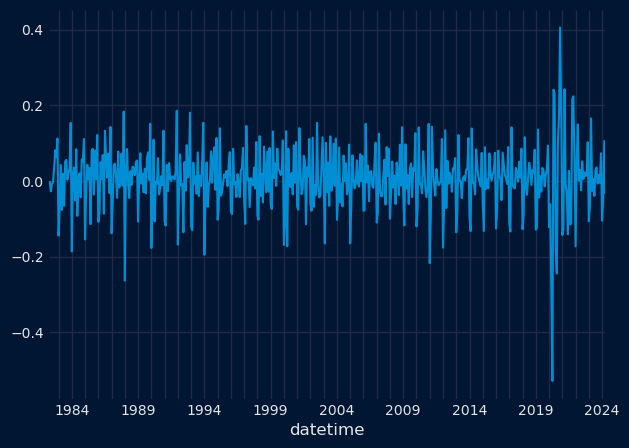

In [8]:
# IMPORTANTE diferenciación para la variable turnover_log, la cual representa nuestra varoable objetivo transformada logarítmicamente
data['turnover_log'] = np.log(data['turnover'])
data['turnover_log_diff'] = data['turnover_log'].diff() 

print('Test de Estacionariedad')
adfuller_result = adfuller(data['turnover_log_diff'].dropna())
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')
data['turnover_log_diff'].plot()
plt.show()

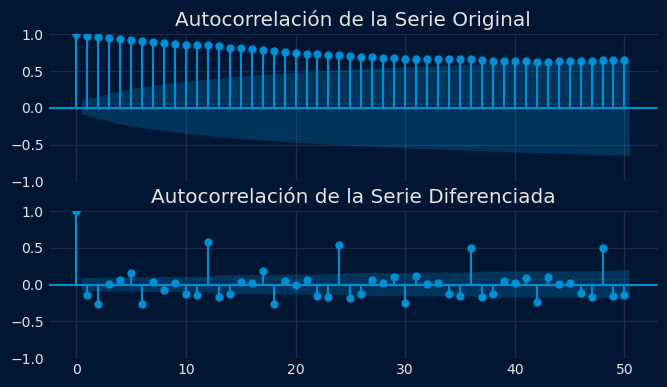

In [9]:
# graficos de correlacion y correlacion parcial
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#Grafico de autocorrelacion

data_log_diff = data['turnover_log'].diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
plot_acf(data['turnover'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación de la Serie Original')
plot_acf(data_log_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación de la Serie Diferenciada')
plt.show()

m = 12   
q = 2

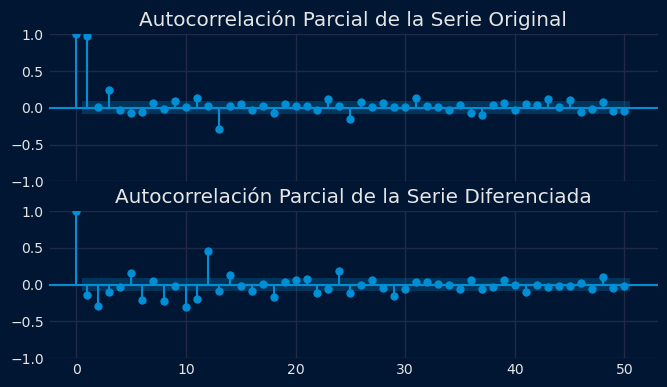

In [10]:
# graficos de correlacion y correlacion parcial
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#Grafico de autocorrelacion parcial
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
plot_pacf(data['turnover'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación Parcial de la Serie Original')
plot_pacf(data_log_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación Parcial de la Serie Diferenciada')
plt.show()

p = 3

Con estas próximas gráficas se quiere ver la serie diferenciada por log y de nuevo la autocorrelación donde se espra ver algún patrón y descubrir la 

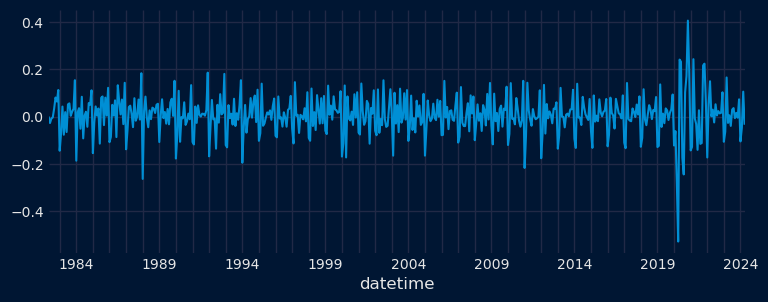

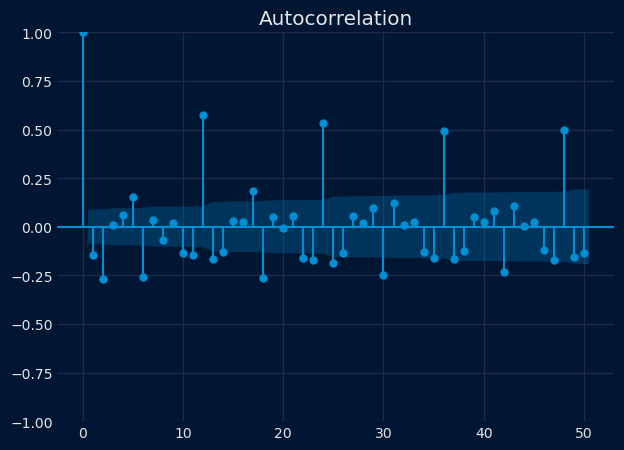

In [11]:
data_log_diff.plot(figsize=(8,3))
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(data_log_diff, lags=50)
plt.show()

Se identifica que después de diferencias aún así se ve un patrón claro en la autocorrelación así que diferenciamos por el periodo 

In [12]:
#Diferenciacion de la serie estacional
data_log_diff_12 = data_log_diff.diff(12).dropna()
print('Test de Estacionalidad (Diferenciación Estacional)')
adfuller_result = adfuller(data_log_diff_12)
print(f'ADF Estadístico (Diferenciación Estacional): {adfuller_result[0]}, p-value: {adfuller_result[1]}')

Test de Estacionalidad (Diferenciación Estacional)
ADF Estadístico (Diferenciación Estacional): -6.221433723347135, p-value: 5.211762039631142e-08


Se cumple el test de adfuller luego de diferenciar una vez 
D = 1

<Figure size 700x300 with 0 Axes>

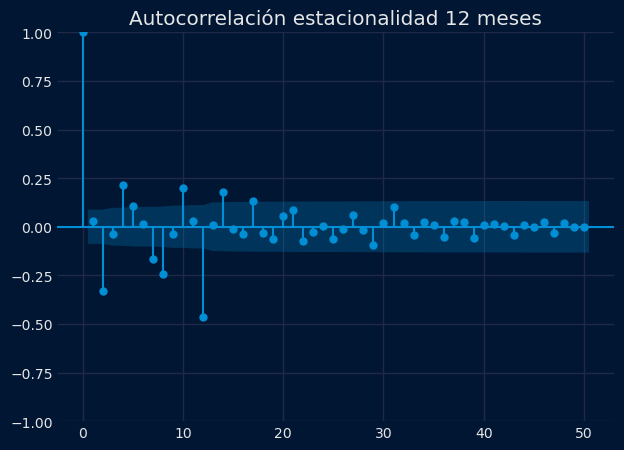

In [13]:
#Grafico de autocorrelacion de la serie estacionaria estacional
plt.figure(figsize=(7, 3))
plot_acf(data_log_diff_12, lags=50, alpha=0.05)
plt.title('Autocorrelación estacionalidad 12 meses')
plt.show()  

Q = 0

<Figure size 700x300 with 0 Axes>

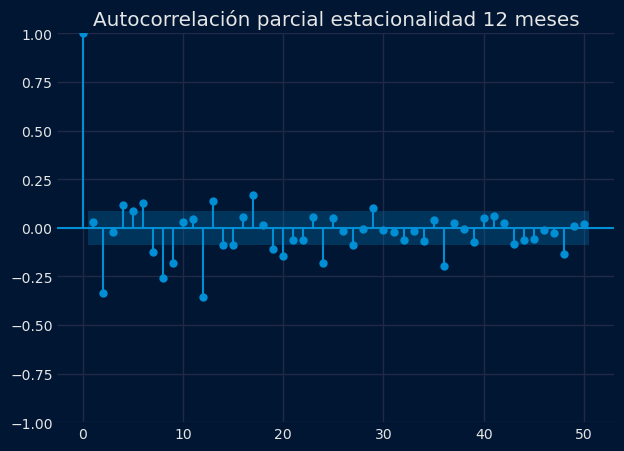

In [14]:
#Grafico de autocorrelacion de la serie estacionaria estacional
plt.figure(figsize=(7, 3))
plot_pacf(data_log_diff_12, lags=50, alpha=0.05)
plt.title('Autocorrelación parcial estacionalidad 12 meses')
plt.show()  

P = 0

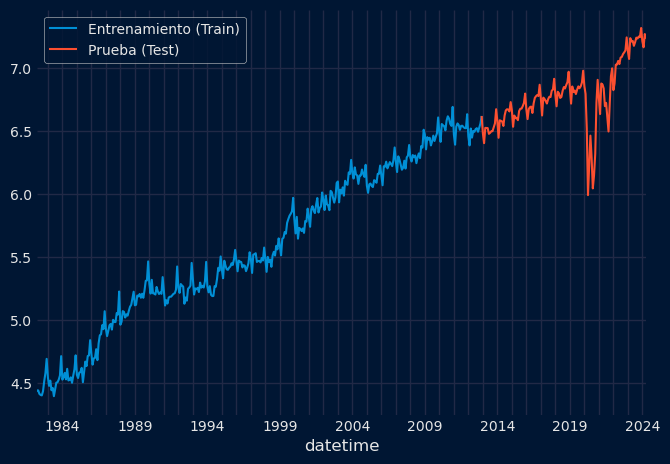

In [15]:
#Separar en datos de entrenamiento y prueba (80%-20%)
end_train_log = '2012-12-01'
data_train_log = data['turnover_log'].loc[:end_train_log]
data_test_log = data['turnover_log'].loc[end_train_log:]
plt.figure(figsize=(7, 5))
data_train_log.plot(label='Entrenamiento (Train)')
data_test_log.plot(label='Prueba (Test)')
plt.legend()
plt.show()

Entrenaremos el modelo con los datos diferenciados de manera log y luego para verificar las predicciones se devuelve a escala original aplicando exp 

In [16]:
# Sarimax
from statsmodels.tsa.statespace.sarimax import SARIMAX
modelo_sarimax_log = SARIMAX(endog = data_train_log, order = (3,1,2), seasonal_order=(0,1,0,12)) #p,d,q P,D,Q,S
modelo_sarimax_log = modelo_sarimax_log.fit(disp = 0)
modelo_sarimax_log.summary()


c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                        turnover_log   No. Observations:                  369
Model:             SARIMAX(3, 1, 2)x(0, 1, [], 12)   Log Likelihood                 558.439
Date:                             Mon, 27 Oct 2025   AIC                          -1104.878
Time:                                     08:12:21   BIC                          -1081.628
Sample:                                 04-01-1982   HQIC                         -1095.629
                                      - 12-01-2012                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1501     14.027     -0.011      0.991     -27.643      27.343
ar.L2          0.0255      7.818      0.003      0.997     -15.297      15.348
ar.L3          0.0627      2.392      0.026      0.979      -4.626       4.752
ma.L1         -0.1149     14.026     -0.008      0.993     -27.606      27.376
ma.L2         -0.0876      4.119     -0.021      0.983      -8.161       7.985
sigma2         0.0025      0.000     14.532      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 6.78
Prob(Q):                              0.99   Prob(JB):                         0.03
Heteroskedasticity (H):               0.83   Skew:                            -0.07
Prob(H) (two-sided):                  0.30   Kurtosis:                         3.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
pred_sarimax_log = modelo_sarimax_log.get_forecast(steps=len(data_test_log)).predicted_mean
pred_sarimax_log.index = data_test_log.index
pred_sarimax_log.name = 'Predicciones SARIMAX'
pred_sarimax_expo = np.exp(pred_sarimax_log)


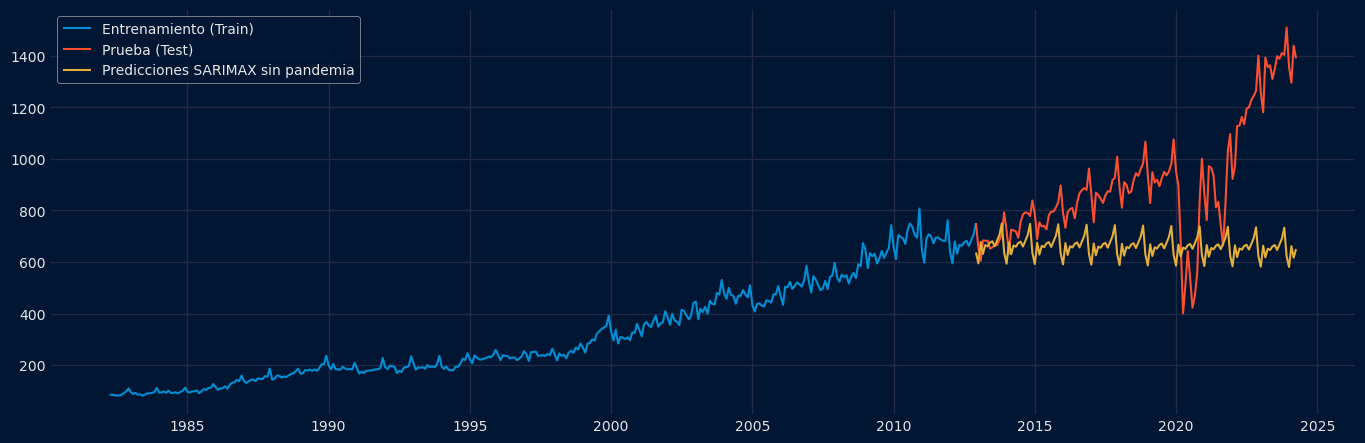

In [18]:
data_train_expo = np.exp(data_train_log)
data_test_expo = np.exp(data_test_log)

plt.figure(figsize=(15, 5))
plt.plot(data_train_expo, label='Entrenamiento (Train)')
plt.plot(data_test_expo, label='Prueba (Test)')
plt.plot(pred_sarimax_expo, label='Predicciones SARIMAX sin pandemia')
plt.legend()
plt.show()

Text(0.5, 0, 'Fecha')

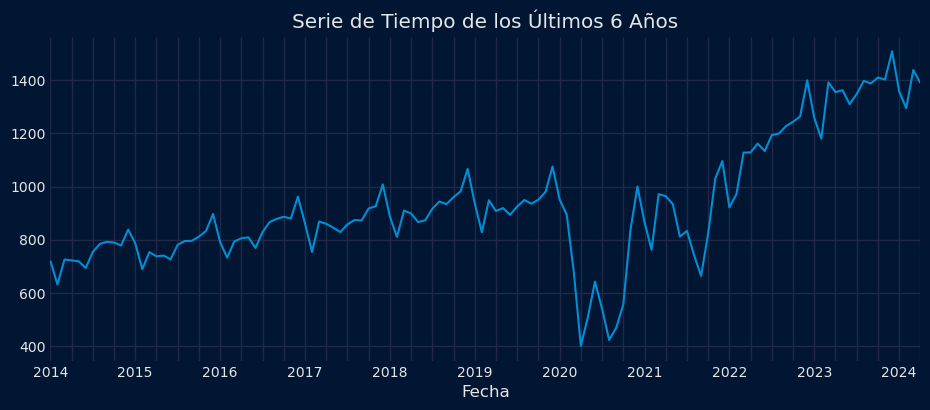

In [19]:
# visualización ultimos 6 anos para ver cambios en pandemia y determianr rango a imputar 
data_6y = data['turnover'].loc['2014-01-01':]
plt.figure(figsize=(10, 4))
data_6y.plot()
plt.title('Serie de Tiempo de los Últimos 6 Años')
plt.xlabel('Fecha')

c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


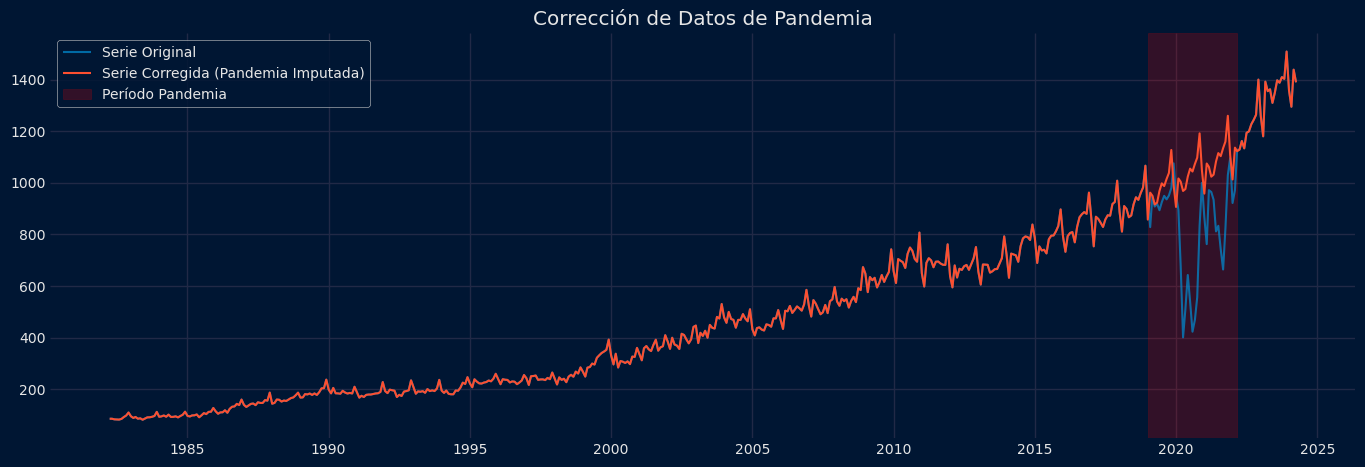

In [20]:
import pandas as pd
# 1. Identificar el período de pandemia
pandemic_start = '2019-01-01'
pandemic_end = '2022-03-01'

# 2. Separar datos pre-pandemia para entrenar
data_pre_pandemic = data['turnover_log'].loc[:pandemic_start]

# 3. Entrenar SARIMAX solo con datos pre-pandemia
modelo_imputacion = SARIMAX(endog=data_pre_pandemic, 
                            order=(3,1,2), 
                            seasonal_order=(0,1,0,12))
modelo_imputacion = modelo_imputacion.fit(disp=0)

# 4. Predecir valores para el período de pandemia
steps_pandemic = len(data['turnover_log'].loc[pandemic_start:pandemic_end])
pred_pandemic = modelo_imputacion.forecast(steps=steps_pandemic)

# 5. Crear serie corregida reemplazando valores de pandemia
data['turnover_log_corrected'] = data['turnover_log'].copy()
data.loc[pandemic_start:pandemic_end, 'turnover_log_corrected'] = pred_pandemic.values

# 6. Visualizar la corrección
plt.figure(figsize=(15, 5))
plt.plot(np.exp(data['turnover_log']), label='Serie Original', alpha=0.7)
plt.plot(np.exp(data['turnover_log_corrected']), label='Serie Corregida (Pandemia Imputada)')
plt.axvspan(pd.to_datetime(pandemic_start), pd.to_datetime(pandemic_end), 
            alpha=0.2, color='red', label='Período Pandemia')
plt.legend()
plt.title('Corrección de Datos de Pandemia')
plt.show()

Text(0.5, 1.0, 'Serie de Tiempo Corregida de los Últimos 10 Años')

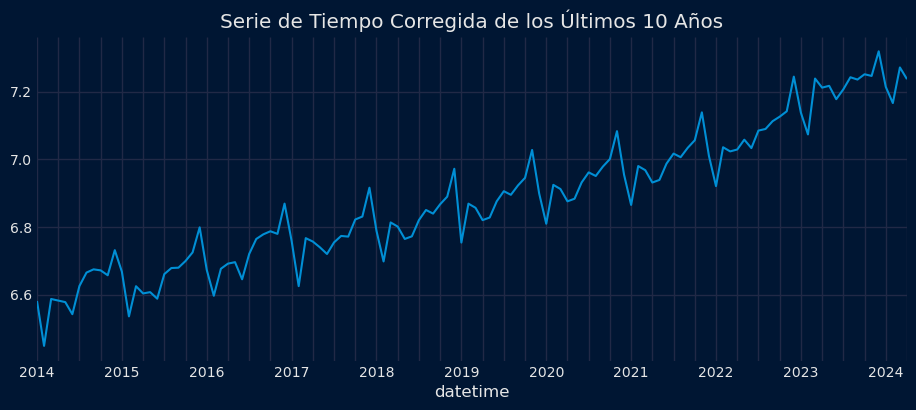

In [21]:
# grafica imputada ultimos 10 anos
data_10y_corrected = data['turnover_log_corrected'].loc['2014-01-01':]
plt.figure(figsize=(10, 4))
data_10y_corrected.plot()
plt.title('Serie de Tiempo Corregida de los Últimos 10 Años')

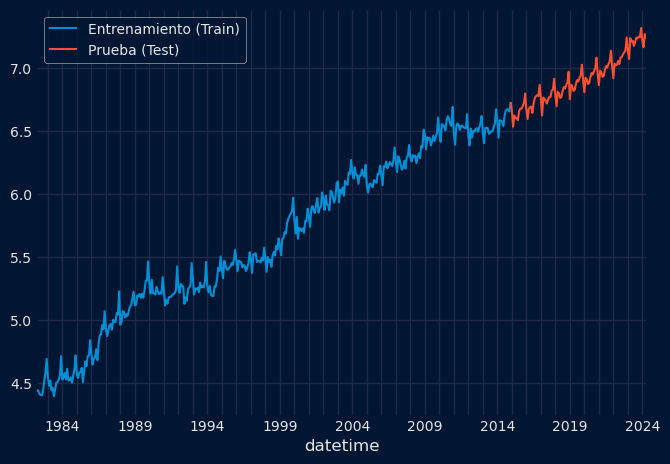

In [22]:
#Separar en datos de entrenamiento y prueba (80%-20%)
end_train_log = '2014-12-01'
data_train_log_corrected = data['turnover_log_corrected'].loc[:end_train_log]
data_test_log_corrected = data['turnover_log_corrected'].loc[end_train_log:]
plt.figure(figsize=(7, 5))
data_train_log_corrected.plot(label='Entrenamiento (Train)')
data_test_log_corrected.plot(label='Prueba (Test)')
plt.legend()
plt.show()

In [23]:
# Sarimax
from statsmodels.tsa.statespace.sarimax import SARIMAX
modelo_sarimax_log_corrected = SARIMAX(endog = data_train_log_corrected, order = (3,1,2), seasonal_order=(2,1,1,12)) #p,d,q P,D,Q,S
modelo_sarimax_log_corrected = modelo_sarimax_log_corrected.fit(disp = 0)
modelo_sarimax_log_corrected.summary()

c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:               turnover_log_corrected   No. Observations:                  393
Model:             SARIMAX(3, 1, 2)x(2, 1, [1], 12)   Log Likelihood                 691.690
Date:                              Mon, 27 Oct 2025   AIC                          -1365.381
Time:                                      08:12:31   BIC                          -1329.919
Sample:                                  04-01-1982   HQIC                         -1351.309
                                       - 12-01-2014                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1756     13.698     -0.013      0.990     -27.022      26.671
ar.L2          0.0601      7.129      0.008      0.993     -13.912      14.032
ar.L3          0.0630      2.138      0.029      0.977      -4.128       4.254
ma.L1         -0.1169     13.692     -0.009      0.993     -26.954      26.720
ma.L2         -0.1158      3.138     -0.037      0.971      -6.267       6.035
ar.S.L12       0.0631      0.065      0.967      0.334      -0.065       0.191
ar.S.L24    1.752e-05      0.062      0.000      1.000      -0.121       0.121
ma.S.L12      -0.8860      0.046    -19.235      0.000      -0.976      -0.796
sigma2         0.0015      0.000     14.013      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.95
Prob(Q):                              0.95   Prob(JB):                         0.23
Heteroskedasticity (H):               0.65   Skew:                            -0.15
Prob(H) (two-sided):                  0.02   Kurtosis:                         3.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
pred_sarimax_log_corrected = modelo_sarimax_log_corrected.get_forecast(steps=len(data_test_log_corrected)).predicted_mean
pred_sarimax_log_corrected.index = data_test_log_corrected.index
pred_sarimax_log_corrected.name = 'Predicciones SARIMAX Corrected'
pred_sarimax_expo_corrected = np.exp(pred_sarimax_log_corrected)


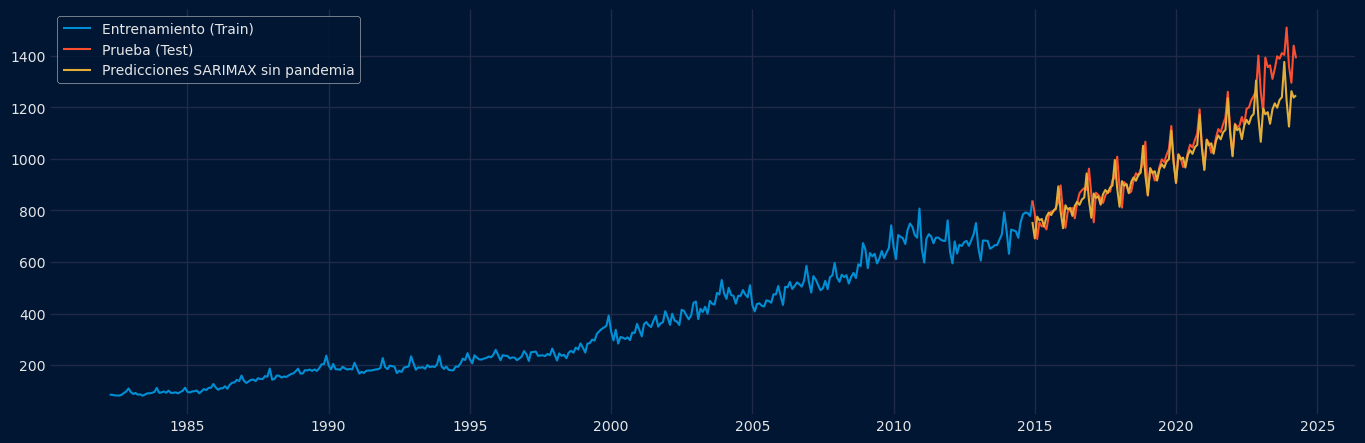

In [25]:
data_train_expo_corrected = np.exp(data_train_log_corrected)
data_test_expo_corrected = np.exp(data_test_log_corrected)

plt.figure(figsize=(15, 5))
plt.plot(data_train_expo_corrected, label='Entrenamiento (Train)')
plt.plot(data_test_expo_corrected, label='Prueba (Test)')
plt.plot(pred_sarimax_expo_corrected, label='Predicciones SARIMAX sin pandemia')
plt.legend()
plt.show()

In [26]:
from sklearn.metrics import mean_absolute_percentage_error
mape_sarimax = mean_absolute_percentage_error(data_test_expo_corrected, pred_sarimax_expo_corrected)
print(f'MAPE SARIMAX: {mape_sarimax:.4f}')

MAPE SARIMAX: 0.0481


In [27]:
#Forecating
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import plot_prediction_intervals

c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


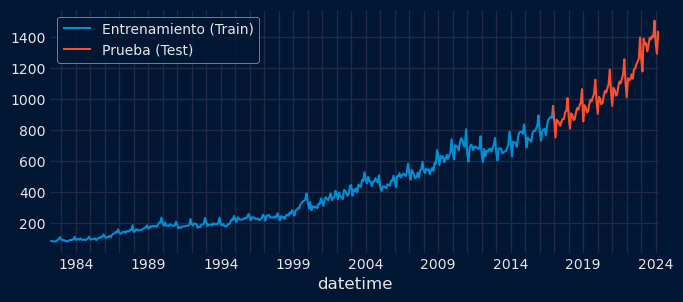

In [35]:
data_end = '2016-12-01'
data_train = data['turnover_log_corrected'].loc[:data_end]
data_test = data['turnover_log_corrected'].loc[data_end:]

data_train_expo_corrected = np.exp(data_train)
data_test_expo_corrected = np.exp(data_test)
plt.figure(figsize=(7, 3))
data_train_expo_corrected.plot(label='Entrenamiento (Train)')
data_test_expo_corrected.plot(label='Prueba (Test)')
plt.legend()
plt.show()

In [36]:
forecaster_1 = ForecasterRecursive(
    regressor = LinearRegression(),
    lags = 24, 
    window_features = RollingFeatures(
        stats=["mean" ],
        window_sizes=10
    ))
forecaster_1.fit(y=data_train, store_in_sample_residuals=True)
forecaster_1

=================== 
ForecasterRecursive 
=================== 
Regressor: LinearRegression 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window features: ['roll_mean_10'] 
Window size: 24 
Series name: turnover_log_corrected 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1982-04-01 00:00:00'), Timestamp('2016-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False} 
fit_kwargs: {} 
Creation date: 2025-10-27 08:28:23 
Last fit date: 2025-10-27 08:28:23 
Skforecast version: 0.18.0 
Python version: 3.13.5 
Forecaster id: None

In [37]:

prediction_1 = forecaster_1.predict(steps=len(data_test))
prediction_1.index = data_test.index
prediction_1

prediction_1_expo = np.exp(prediction_1)


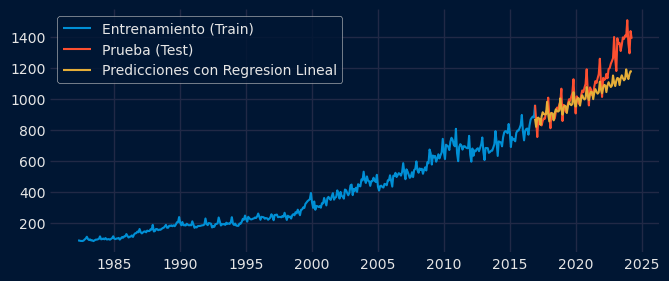

In [38]:
plt.figure(figsize=(7, 3))
plt.plot(data_train_expo_corrected, label='Entrenamiento (Train)')
plt.plot(data_test_expo_corrected, label='Prueba (Test)')
plt.plot(prediction_1_expo, label='Predicciones con Regresion Lineal')
plt.legend()
plt.show()

In [39]:
mean_absolute_percentage_error(data_test_expo_corrected, prediction_1_expo)

0.07037101624499516

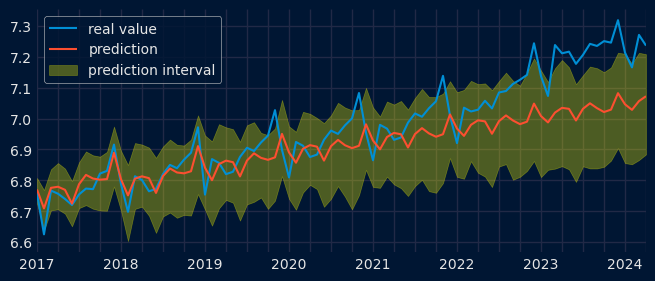

In [40]:
prediction_1_interval = forecaster_1.predict_interval(steps=len(data_test) -1,
                                                      interval=[5, 95],
                                                    method='bootstrapping', n_boot=100)
plot_prediction_intervals(predictions=prediction_1_interval, y_true=data_test, target_variable='turnover_log_corrected',
                          kwargs_fill_between={'color': 'yellow', 'alpha':0.3})
plt.show()

In [41]:
forecaster_2 = ForecasterRecursive(regressor=DecisionTreeRegressor(random_state=42),
                                 lags=24, window_features=RollingFeatures(stats=['mean' , 'std'], window_sizes=10))
forecaster_2.fit(y=data_train, store_in_sample_residuals=True)
forecaster_2    

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window features: ['roll_mean_10', 'roll_std_10'] 
Window size: 24 
Series name: turnover_log_corrected 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1982-04-01 00:00:00'), Timestamp('2016-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-27 08:28:43 
Last fit date: 2025-10-27 08:28:43 
Skforecast version: 0.18.0 
Python version: 3.13.5 
Forecaster id: None

In [42]:
prediction_2 = forecaster_2.predict(steps=len(data_test))
prediction_2

prediction_2_expo = np.exp(prediction_2)

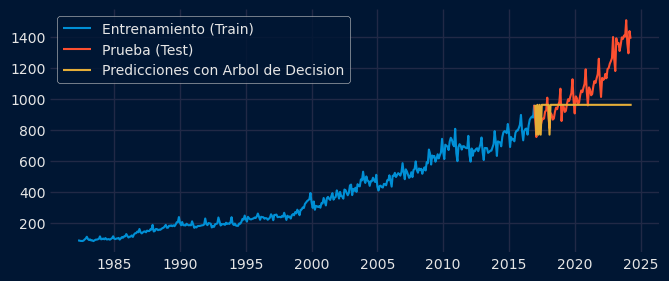

In [43]:
plt.figure(figsize=(7, 3))
plt.plot(data_train_expo_corrected, label='Entrenamiento (Train)')
plt.plot(data_test_expo_corrected, label='Prueba (Test)')
plt.plot(prediction_2_expo, label='Predicciones con Arbol de Decision')
plt.legend()
plt.show()

In [186]:
mean_absolute_percentage_error(data_test_expo_corrected, prediction_2_expo)

0.23174895555982145

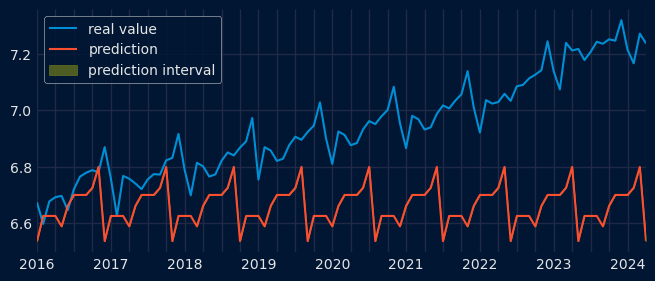

In [188]:
prediction_2_interval = forecaster_2.predict_interval(steps=len(data_test) -1,
                                                      interval=[5, 95],
                                                    method='bootstrapping', n_boot=100)
plot_prediction_intervals(predictions=prediction_2_interval, y_true=data_test, target_variable='turnover_log_corrected',
                          kwargs_fill_between={'color': 'yellow', 'alpha':0.3})
plt.show()

In [204]:
from skforecast.model_selection import grid_search_forecaster, random_search_forecaster, TimeSeriesFold
forecaster_3 = ForecasterRecursive(
    regressor = RandomForestRegressor(random_state = 42),
    lags = 10
)

# Busqueda de la ventana
lags_grid = {'lags_1':3, 'lags_2':10, 'lags_3':[1,2,3,12]} # Cada 7 periodos hay un evento que se repite

# Busqueda de hiperparametros del regresor
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['squared_error', 'friedman_mse']
}

# Folds
cv = TimeSeriesFold(
    steps = 7,
    initial_train_size = len(data_test),
    refit = False
)

# Implementacion de la busqueda de hiperparametros
result = grid_search_forecaster(
    forecaster = forecaster_3,
    y = data_train,
    param_grid = param_grid,
    lags_grid = lags_grid,
    cv = cv,
    metric = 'mean_squared_error',
    return_best = True,
    n_jobs = -1,
    verbose = False,
    show_progress = True
)

result

lags grid: 100%|██████████| 3/3 [22:34<00:00, 451.48s/it]


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3 12] 
  Parameters: {'criterion': 'squared_error', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Backtesting metric: 0.5943043029469226


,lags,lags_label,params,mean_squared_error,criterion,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
0,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 5,...",0.594304,squared_error,5,sqrt,1,2,200
1,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 5,...",0.594304,squared_error,5,log2,1,2,200
2,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 5, ...",0.598479,friedman_mse,5,log2,1,2,200
3,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 5, ...",0.598479,friedman_mse,5,sqrt,1,2,200
4,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 10...",0.600608,squared_error,10,log2,1,2,200
...,...,...,...,...,...,...,...,...,...,...
283,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'squared_error', 'max_depth': 10...",0.739947,squared_error,10,sqrt,1,2,500
284,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'friedman_mse', 'max_depth': 15,...",0.741063,friedman_mse,15,log2,1,2,500
285,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'friedman_mse', 'max_depth': 15,...",0.741063,friedman_mse,15,sqrt,1,2,500
286,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'friedman_mse', 'max_depth': 10,...",0.741635,friedman_mse,10,log2,1,2,500


In [205]:
forecaster_3


=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3 12] 
Window features: None 
Window size: 12 
Series name: turnover_log_corrected 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1982-04-01 00:00:00'), Timestamp('2015-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200,
    'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-26 17:53:18 
Last fit date: 2025-10-26 18:15:53 
Skforecast version: 0.18.0 
Python version: 3.13.5 
Forecaster id: None

In [206]:
prediction_3 = forecaster_3.predict(steps=len(data_test))
prediction_3

prediction_3_expo = np.exp(prediction_3)

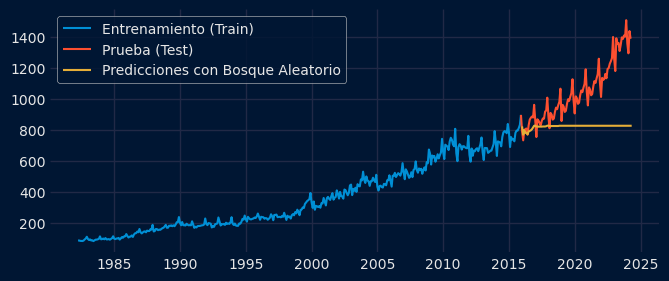

In [209]:
plt.figure(figsize=(7, 3))
plt.plot(data_train_expo_corrected, label='Entrenamiento (Train)')
plt.plot(data_test_expo_corrected, label='Prueba (Test)')
plt.plot(prediction_3_expo, label='Predicciones con Bosque Aleatorio')
plt.legend()
plt.show()

In [210]:
mean_absolute_percentage_error(data_test_expo, prediction_3_expo)

0.2036670015013582

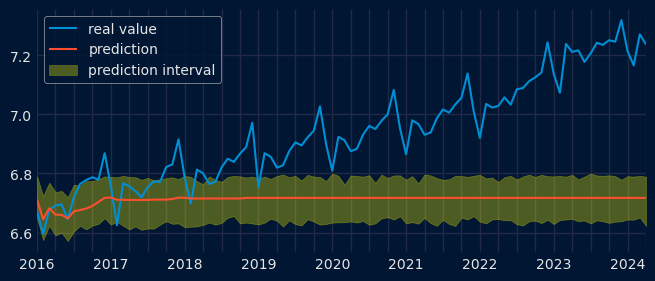

In [211]:
prediction_3_interval = forecaster_3.predict_interval(steps=len(data_test) -1,
                                                      interval=[5, 95],
                                                    method='bootstrapping', n_boot=100)
plot_prediction_intervals(predictions=prediction_3_interval, y_true=data_test, target_variable='turnover_log_corrected',
                          kwargs_fill_between={'color': 'yellow', 'alpha':0.3})
plt.show()

# Redes Neuronales

In [212]:
#Redes neuronales artificiales

from skforecast.deep_learning import ForecasterRnn, create_and_compile_model
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler

c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid

In [214]:
model_rna = create_and_compile_model(series=pd.DataFrame(data_train),
                                     levels=['turnover_log_corrected'], lags=24, steps=1, recurrent_layer='RNN', recurrent_units=100, dense_units=64)
model_rna.summary()

keras version: 3.11.3
Using backend: tensorflow
tensorflow version: 2.20.0



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,729 (65.35 KB)

 Trainable params: 16,729 (65.35 KB)

 Non-trainable params: 0 (0.00 B)

In [216]:
forecaster_4 = ForecasterRnn(regressor=model_rna,
                             levels=['turnover_log_corrected'],
                             lags=24,
                             transformer_series=MinMaxScaler(),
                             fit_kwargs={
                                 'epochs':25,
                                 'batch_size':512,
                                 'callbacks':[EarlyStopping(monitor='val_loss', restore_best_weights=True)],
                                 'series_val': pd.DataFrame(data_test)})
forecaster_4.fit(pd.DataFrame(data_train))
forecaster_4


Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1753 - val_loss: 0.0978
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.0108 - val_loss: 0.0077
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0224 - val_loss: 0.0443


============= 
ForecasterRnn 
============= 
Regressor: <Functional name=functional, built=True> 
Layers names: ['series_input', 'rnn_1', 'dense_1', 'output_dense_td_layer', 'reshape'] 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window size: 24 
Maximum steps to predict: [1] 
Series names: turnover_log_corrected 
Target series (levels): ['turnover_log_corrected'] 
Exogenous included: False 
Exogenous names: None 
Transformer for series: MinMaxScaler() 
Transformer for exog: MinMaxScaler() 
Training range: [Timestamp('1982-04-01 00:00:00'), Timestamp('2015-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: {'name': 'functional', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 24, 1), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'series_input'}, 'registered_name': None, 'name': 'series_input', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'SimpleRNN', 'config': {'name': 'rnn_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'return_sequences': False, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'zero_output_for_mask': False, 'units': 100, 'activation': 'tanh', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'seed': None, 'gain': 1.0}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'recurrent_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'recurrent_constraint': None, 'bias_constraint': None, 'dropout': 0.0, 'recurrent_dropout': 0.0}, 'registered_name': None, 'build_config': {'input_shape': [None, 24, 1]}, 'name': 'rnn_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 24, 1), 'dtype': 'float32', 'keras_history': ['series_input', 0, 0]}},), 'kwargs': {'training': False, 'mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 64, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 100]}, 'name': 'dense_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 100), 'dtype': 'float32', 'keras_history': ['rnn_1', 0, 0]}},), 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'output_dense_td_layer', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 1, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64]}, 'name': 'output_dense_td_layer', 'in

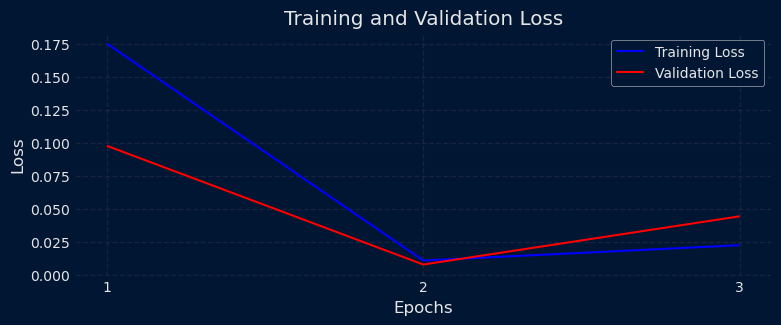

In [217]:
fig, ax = plt.subplots(figsize=(8, 3))
plot = forecaster_4.plot_history(ax=ax)

In [218]:
from skforecast.model_selection import backtesting_forecaster_multiseries
cv = TimeSeriesFold(
    steps = forecaster_4.max_step,
    initial_train_size = len(data_test),
    refit = False
)
metrics, prediction_4 = backtesting_forecaster_multiseries(forecaster=forecaster_4,
                                              series=pd.DataFrame(data_train),
                                              cv=cv,
                                              levels = forecaster_4.levels,
                                              metric = 'mean_squared_error', verbose=False)

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0164 - val_loss: 1.3736
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0153 - val_loss: 1.2954


100%|██████████| 304/304 [00:27<00:00, 11.24it/s]


In [219]:
metrics

,levels,mean_squared_error
0,turnover_log_corrected,0.37366


In [220]:
prediction_4

,level,fold,pred
1990-09-01,turnover_log_corrected,0,5.057465
1990-10-01,turnover_log_corrected,1,5.048683
1990-11-01,turnover_log_corrected,2,5.071724
1990-12-01,turnover_log_corrected,3,5.053743
1991-01-01,turnover_log_corrected,4,5.064373
...,...,...,...
2015-08-01,turnover_log_corrected,299,5.665220
2015-09-01,turnover_log_corrected,300,5.679454
2015-10-01,turnover_log_corrected,301,5.664570
2015-11-01,turnover_log_corrected,302,5.669772


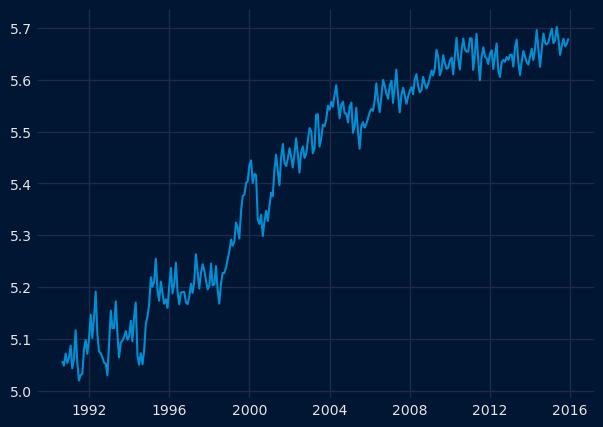

In [221]:
plt.plot(prediction_4['pred'])